# Семинар 4. Ивентовые данные. Детекция действий по видео модальности.
Подготовил: Дурыгин Олег

Данные: ивентовые данные от [StatsBomb](https://github.com/statsbomb/open-data/tree/master)

## 1. Installation and download data

In [2]:
! pip install mplsoccer gigachat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.3 MB/s eta 0:00:00


## Блок 2. Показ ивентовых данных с помощью mplsoccer


In [3]:
from mplsoccer import Pitch, FontManager, Sbopen
import matplotlib.patheffects as path_effects

# read data
parser = Sbopen()
df, related, freeze, tactics = parser.event(2302764)

# get the team names
team1, team2 = df.team_name.unique()
df.type_name.unique()

array(['Starting XI', 'Half Start', 'Pass', 'Ball Receipt', 'Carry',
       'Pressure', 'Dispossessed', 'Duel', 'Foul Committed', 'Foul Won',
       'Shot', 'Goal Keeper', 'Clearance', 'Dribble', 'Block',
       'Ball Recovery', 'Interception', 'Dribbled Past', 'Miscontrol',
       'Shield', 'Offside', 'Substitution', 'Tactical Shift', 'Half End',
       '50/50', 'Error', 'Player Off', 'Referee Ball-Drop', 'Player On',
       'Injury Stoppage'], dtype=object)

In [4]:
# exploring the data
df.info()
related.info()
freeze.info()
tactics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4648 entries, 0 to 4647
Data columns (total 78 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              4648 non-null   object 
 1   index                           4648 non-null   int64  
 2   period                          4648 non-null   int64  
 3   timestamp                       4648 non-null   object 
 4   minute                          4648 non-null   int64  
 5   second                          4648 non-null   int64  
 6   possession                      4648 non-null   int64  
 7   duration                        3452 non-null   float64
 8   match_id                        4648 non-null   int64  
 9   type_id                         4648 non-null   int64  
 10  type_name                       4648 non-null   object 
 11  possession_team_id              4648 non-null   int64  
 12  possession_team_name            46

In [9]:
event_type = "Carry"
is_1_team_is_main_team = False
if is_1_team_is_main_team:
    team1, team2 = team1, team2
else:
    team2, team1 = team1, team2

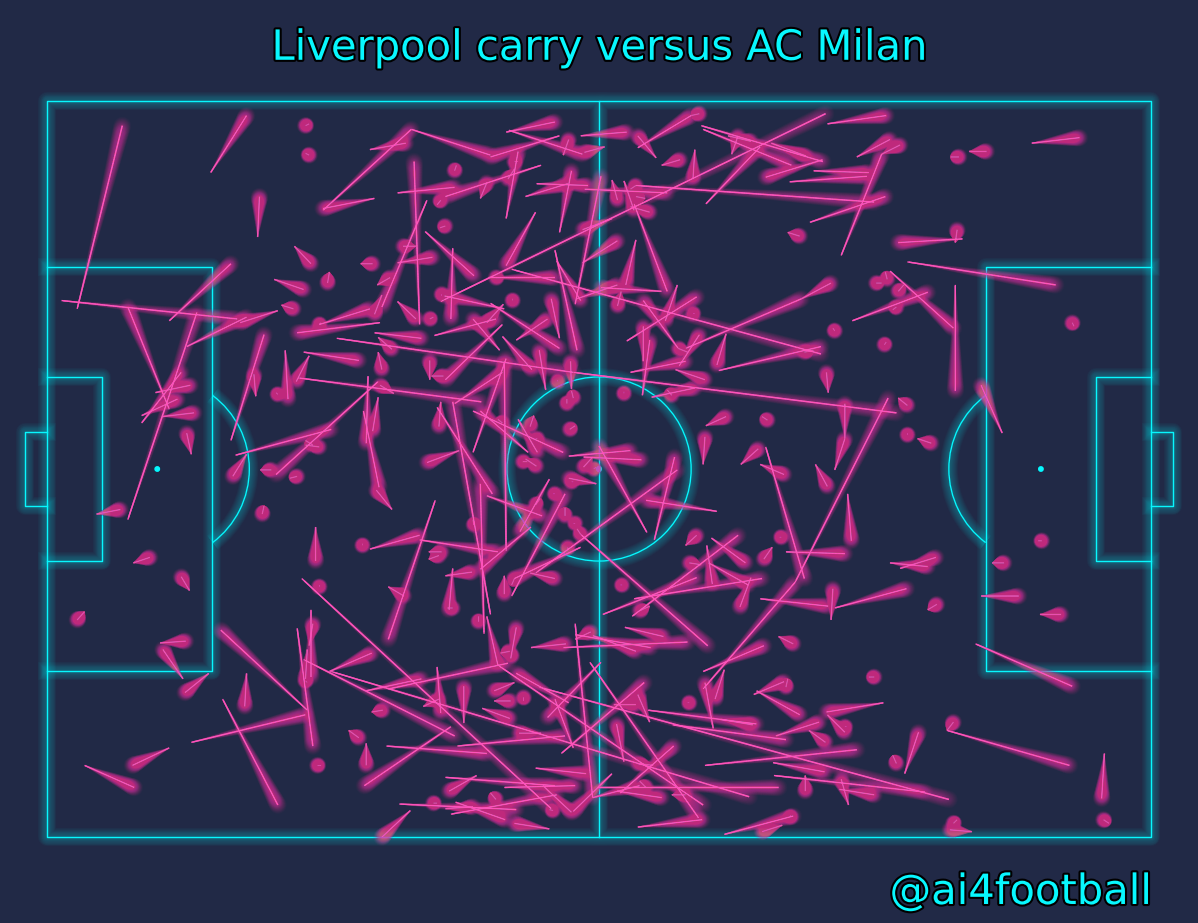

In [10]:
mask_team1 = (df.type_name == event_type) & (df.team_name == team1)
df_event = df.loc[mask_team1, ['x', 'y', 'end_x', 'end_y', 'outcome_name']]

LINEWIDTH = 1  # starting linewidth
DIFF_LINEWIDTH = 1.2  # amount the glow linewidth increases each loop
NUM_GLOW_LINES = 10  # the amount of loops, if you increase the glow will be wider

ALPHA_PITCH_LINE = 0.3
ALPHA_EVENT_LINE = 0.15

# The colors are borrowed from mplcyberpunk. Try some of the following alternatives
# '#08F7FE' (teal/cyan), '#FE53BB' (pink), '#F5D300' (yellow),
# '#00ff41' (matrix green), 'r' (red), '#9467bd' (viloet)
BACKGROUND_COLOR = '#212946'
EVENT_COLOR = '#FE53BB'
LINE_COLOR = '#08F7FE'

# plot as initial pitch and the lines with alpha=1
# I have used grid to get a title and endnote axis automatically, but you could you pitch.draw()
pitch = Pitch(line_color=LINE_COLOR, pitch_color=BACKGROUND_COLOR, linewidth=LINEWIDTH,
              line_alpha=1, goal_alpha=1, goal_type='box')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
fig.set_facecolor(BACKGROUND_COLOR)
pitch.lines(df_event.x, df_event.y,
            df_event.end_x, df_event.end_y,
            capstyle='butt',  # cut-off the line at the end-location.
            linewidth=LINEWIDTH, color=EVENT_COLOR, comet=True, ax=ax['pitch'])

# plotting the titles and endnote
text_effects = [path_effects.Stroke(linewidth=3, foreground='black'),
                path_effects.Normal()]
ax['title'].text(0.5, 0.3, f'{team1} {event_type.lower()} versus {team2}',
                 path_effects=text_effects,
                 va='center', ha='center', color=LINE_COLOR, fontsize=30)
ax['endnote'].text(1, 0.5, '@ai4football', va='center', path_effects=text_effects,
                   ha='right', color=LINE_COLOR, fontsize=30)

for i in range(1, NUM_GLOW_LINES + 1):
    pitch = Pitch(line_color=LINE_COLOR, pitch_color=BACKGROUND_COLOR,
                  linewidth=LINEWIDTH + (DIFF_LINEWIDTH * i),
                  line_alpha=ALPHA_PITCH_LINE / NUM_GLOW_LINES,
                  goal_alpha=ALPHA_PITCH_LINE / NUM_GLOW_LINES,
                  goal_type='box')
    pitch.draw(ax=ax['pitch'])  # we plot on-top of our previous axis from pitch.grid
    pitch.lines(df_event.x, df_event.y,
                df_event.end_x, df_event.end_y,
                linewidth=LINEWIDTH + (DIFF_LINEWIDTH * i),
                capstyle='round',  # capstyle round so the glow extends past the line
                alpha=ALPHA_EVENT_LINE / NUM_GLOW_LINES,
                color=EVENT_COLOR, comet=True, ax=ax['pitch'])

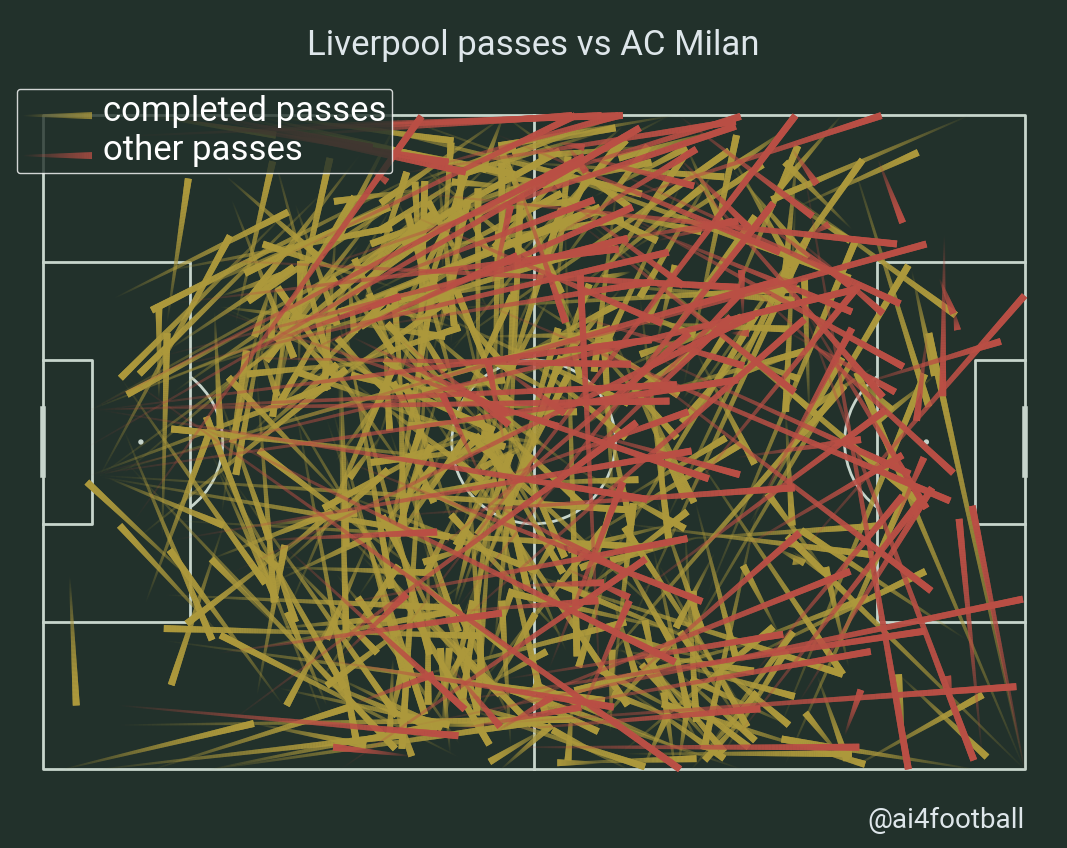

In [11]:
mask_team1 = (df.type_name == 'Pass') & (df.team_name == team1)
df_pass = df.loc[mask_team1, ['x', 'y', 'end_x', 'end_y', 'outcome_name']]
mask_complete = df_pass.outcome_name.isnull()

pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='#c7d5cc')
fig, axs = pitch.grid(endnote_height=0.03, endnote_space=0, figheight=12,
                      title_height=0.06, title_space=0,
                      # Turn off the endnote/title axis. I usually do this after
                      # I am happy with the chart layout and text placement
                      axis=False,
                      grid_height=0.6)
fig.set_facecolor('#22312b')

# Plot the completed passes
lc1 = pitch.lines(df_pass[mask_complete].x, df_pass[mask_complete].y,
                  df_pass[mask_complete].end_x, df_pass[mask_complete].end_y,
                  lw=5, transparent=True, comet=True, label='completed passes',
                  color='#ad993c', ax=axs['pitch'])

# Plot the other passes
lc2 = pitch.lines(df_pass[~mask_complete].x, df_pass[~mask_complete].y,
                  df_pass[~mask_complete].end_x, df_pass[~mask_complete].end_y,
                  lw=5, transparent=True, comet=True, label='other passes',
                  color='#ba4f45', ax=axs['pitch'])

# fontmanager for google font (robotto)
robotto_regular = FontManager()

# setup the legend
legend = axs['pitch'].legend(facecolor='#22312b', handlelength=5, edgecolor='white',
                             labelcolor='white',
                             prop=robotto_regular.prop, loc='upper left')
for text in legend.get_texts():
    text.set_fontsize(25)

# endnote and title
axs['endnote'].text(1, 0.5, '@ai4football', va='center', ha='right', fontsize=20,
                    fontproperties=robotto_regular.prop, color='#dee6ea')
ax_title = axs['title'].text(0.5, 0.5, f'{team1} passes vs {team2}', color='#dee6ea',
                             va='center', ha='center',
                             fontproperties=robotto_regular.prop, fontsize=25)

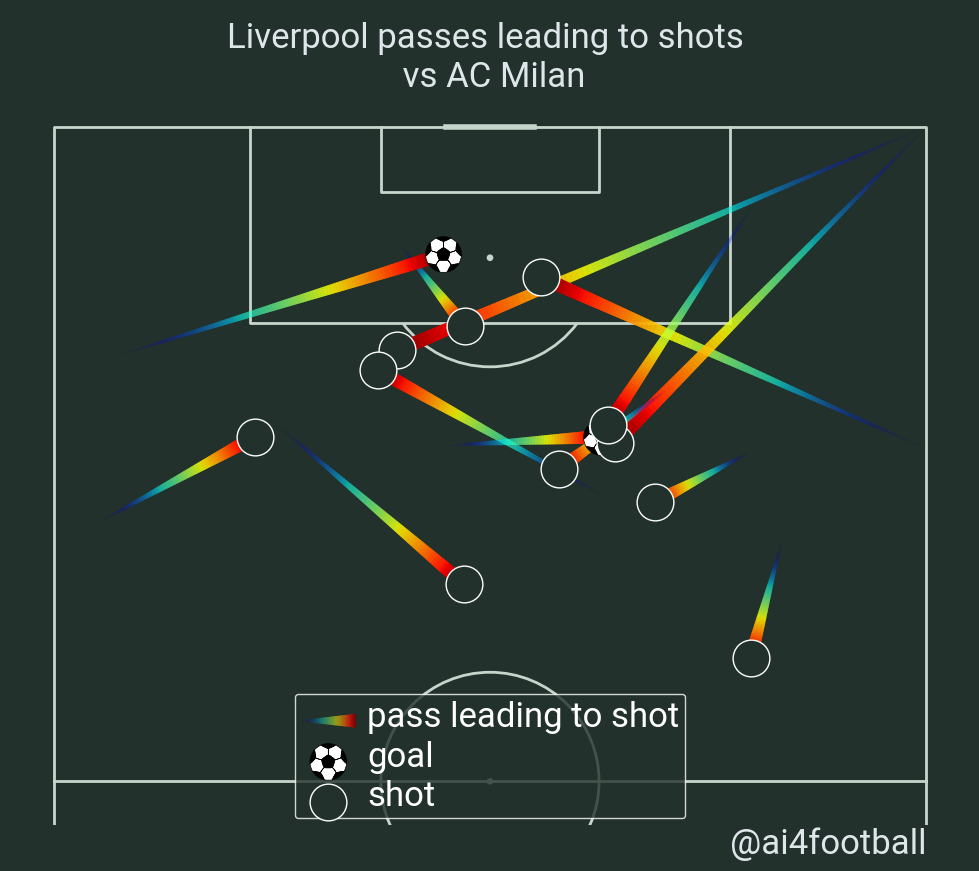

In [12]:
from mplsoccer import Pitch, VerticalPitch, FontManager, Sbopen

df_pass = df.loc[(df.pass_assisted_shot_id.notnull()) & (df.team_name == team1),
                 ['x', 'y', 'end_x', 'end_y', 'pass_assisted_shot_id']]

df_shot = (df.loc[(df.type_name == 'Shot') & (df.team_name == team1),
                  ['id', 'outcome_name', 'shot_statsbomb_xg']]
           .rename({'id': 'pass_assisted_shot_id'}, axis=1))

df_pass = df_pass.merge(df_shot, how='left').drop('pass_assisted_shot_id', axis=1)

mask_goal = df_pass.outcome_name == 'Goal'

# Setup the pitch
pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='#c7d5cc',
                      half=True, pad_top=2)
fig, axs = pitch.grid(endnote_height=0.03, endnote_space=0, figheight=12,
                      title_height=0.08, title_space=0, axis=False,
                      grid_height=0.6)
fig.set_facecolor('#22312b')

# Plot the completed passes
pitch.lines(df_pass.x, df_pass.y, df_pass.end_x, df_pass.end_y,
            lw=10, transparent=True, comet=True, cmap='jet',
            label='pass leading to shot', ax=axs['pitch'])

# Plot the goals
pitch.scatter(df_pass[mask_goal].end_x, df_pass[mask_goal].end_y, s=700,
              marker='football', edgecolors='black', c='white', zorder=2,
              label='goal', ax=axs['pitch'])
pitch.scatter(df_pass[~mask_goal].end_x, df_pass[~mask_goal].end_y,
              edgecolors='white', c='#22312b', s=700, zorder=2,
              label='shot', ax=axs['pitch'])

# endnote and title
axs['endnote'].text(1, 0.5, '@ai4football', va='center', ha='right', fontsize=25,
                    fontproperties=robotto_regular.prop, color='#dee6ea')
axs['title'].text(0.5, 0.5, f'{team1} passes leading to shots \n vs {team2}', color='#dee6ea',
                  va='center', ha='center',
                  fontproperties=robotto_regular.prop, fontsize=25)

# set legend
legend = axs['pitch'].legend(facecolor='#22312b', edgecolor='white', labelcolor='white',
                             loc='lower center', handlelength=4)
for text in legend.get_texts():
    text.set_fontproperties(robotto_regular.prop)
    text.set_fontsize(25)

## Блок 3. Описание кадра с помощью VLM


In [14]:
import cv2
import requests
import json
import base64
from pathlib import Path

def cv2_image_to_base64(image_np_array, format=".jpg", quality=90):
    """
    Converts an OpenCV image (NumPy array) to a base64 encoded string.

    Args:
        image_np_array (numpy.ndarray): The OpenCV image as a NumPy array.
        format (str): The image format to encode to (e.g., ".jpg", ".png").
        quality (int): For JPEG, the quality from 0-100. Ignored for other formats.

    Returns:
        str: The base64 encoded string of the image.
    """
    if image_np_array is None:
        return None

    # Encode the image into a byte buffer
    if format == ".jpg":
        encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    elif format == ".png":
        encode_param = [int(cv2.IMWRITE_PNG_COMPRESSION), 9] # PNG compression level 0-9
    else:
        encode_param = None # Use default parameters for other formats

    result, buffer = cv2.imencode(format, image_np_array, encode_param)

    if not result:
        raise ValueError("Could not encode image.")

    # Base64 encode the buffer and decode to a string
    base64_encoded_image = base64.b64encode(buffer).decode("utf-8")
    return base64_encoded_image

def encode_image_to_base64(image_path):
    if isinstance(image_path, str) or isinstance(image_path, Path):
        with open(image_path, "rb") as image_file:
            return base64.b64encode(image_file.read()).decode('utf-8')
    else:
        return cv2_image_to_base64(image_path)

def fig2numpy(fig):
    """Converts a matplotlib figure to a numpy RGBA array."""
    fig.canvas.draw()
    # Get the RGBA buffer and convert to numpy array
    return np.array(fig.canvas.renderer.buffer_rgba())[:,:,:3]

In [15]:
import numpy as np
minimap_image = fig2numpy(fig)
base64_minimap_image = encode_image_to_base64(minimap_image)
data_url = f"data:image/jpeg;base64,{base64_minimap_image}"

In [20]:
messages = [
    {
        "role": "system",
        "content": [
            {
                "type": "text",
                "text": """
                    Вы — профессиональный аналитик футбольных матчей мирового уровня.
                    Вы анализируете один кадр из футбольного матча или визуализации связанные с футболом.
                    Ваша задача - определить, что происходит на этом кадре. Ответ необходимо вернуть на русском языке
                """
            },
        ]
    },
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": """
                Проанализируйте предоставленный кадр и расскажи откуда были забиты голы
                """
            },
            {
                "type": "image_url",
                "image_url": {
                    "url": data_url
                }
            },
        ]
    }
]

### OpenRouter

In [17]:
from google.colab import userdata
API_KEY_REF = userdata.get('open_router_token')

In [21]:
url = "https://openrouter.ai/api/v1/chat/completions"
headers = {
    "Authorization": f"Bearer {API_KEY_REF}",
    "Content-Type": "application/json"
}

payload = {
    "model": "openrouter/healer-alpha",
    "messages": messages,
}

response = requests.post(url, headers=headers, json=payload)
data = response.json()

In [19]:
data['choices'][0]['message']["content"]

'Это аналитическая визуализация, показывающая комбинации команды **«Ливпуль»**, которые завершились ударами по воротам в матче против **«Милана»**.\n\nВот основные выводы по кадру:\n\n1.  **Концентрация в атаке:** Большинство опасных передач, приведших к ударам, начинались или завершались в атакующей трети поля, особенно плотно — в районе штрафной площади и вокруг неё. Это говорит о высоком прессинге и быстром продвигании мяча «Ливпулем».\n\n2.  **Тип атак:** Присутствует множество **коротких и средних передач** (синие и голубые стрелки), особенно в центральной и левой зонах атаки. Это указывает на попытки комбинационного прохода через центр и левый фланг.\n\n3.  **Удалённые атаки:** Есть несколько длинных передач с флангов и центра поля (зелёные и жёлтые стрелки), которые также привели к ударам. Это может свидетельствовать о быстрых контратаках или розыгрыше стандартных положений.\n\n4.  **Результативность:** На схеме обозначен **один гол** (иконка мяча в воротах), который был забит п

In [22]:
data['choices'][0]['message']["content"]

'На предоставленной визуализации (которая отображает пассы Ливерпуля, ведущие к ударам, в матче с АК Миланом) есть обозначение **гола** (иконка футбольного мячика).  \n\nГол был забит **внутри штрафной площади**, ближе к левой стойке ворот (с точки зрения атакующей команды — Ливерпуля). Это следует из того, что иконка гола размещена именно в этой зоне, рядом с местом завершающего удара (которые обозначены кругами).  \n\nВизуализация фокусируется на пасах, ведущих к ударам, но единственный обозначенный гол локализован вблизи ворот в пределах штрафной площади.'

### Giga Chat

In [23]:
cv2.imwrite("/content/frame_giga.png", cv2.cvtColor(minimap_image, cv2.COLOR_RGB2BGR))

True

[GIGACHAT документация](https://developers.sber.ru/docs/ru/gigachain/tools/python/gigachat)

In [24]:
GIGACHAT_SCOPE=userdata.get('GIGACHAT_SCOPE')
GIGACHAT_CREDENTIALS=userdata.get('GIGACHAT_CREDENTIALS')

In [25]:
giga_messages = messages.copy()
giga_messages[0]["content"] = giga_messages[0]["content"][0]["text"]
giga_messages[1]["content"] = giga_messages[1]["content"][0]["text"]

In [26]:
from gigachat import GigaChat
import io

# Укажите ключ авторизации, полученный в личном кабинете, в интерфейсе проекта GigaChat API
with GigaChat(
    credentials=GIGACHAT_CREDENTIALS,
    scope=GIGACHAT_SCOPE,
    verify_ssl_certs=False,
    model="GigaChat-2-Max"
) as giga:
    file_frame = giga.upload_file(open("/content/frame_giga.png", "rb"))

    giga_messages[0]["attachments"] = []
    giga_messages[1]["attachments"] = [file_frame.id_,]
    result = giga.chat(
        {
            "messages": giga_messages,
        }
    )

    print(result.choices[0].message.content)

На изображении представлена визуализация пасов, приведших к ударам по воротам в матче между Ливерпулем и Миланом. 

На поле изображены линии, соединяющие игроков, которые обозначают пасы. Цвета линий указывают на результат паса: 

- Зеленый - пас, приведший к удару по воротам.
- Красный - пас, приведший к голу.
- Другие цвета - обычные пасы.

На изображении видно, что один из ударов по воротам был забит после паса из центральной части поля, а другой - после паса с правого фланга.


https://github.com/shufinskiy/sport_analytics_tools/tree/main/whoscored_light

Парсер ивентовых данных